In [5]:
import pandas as pd


url="https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df=pd.read_csv(url)

print(df.head())
print(df.columns)
print(df.info())

print(df.shape)

       country  year         pop continent  lifeExp   gdpPercap
0  Afghanistan  1952   8425333.0      Asia   28.801  779.445314
1  Afghanistan  1957   9240934.0      Asia   30.332  820.853030
2  Afghanistan  1962  10267083.0      Asia   31.997  853.100710
3  Afghanistan  1967  11537966.0      Asia   34.020  836.197138
4  Afghanistan  1972  13079460.0      Asia   36.088  739.981106
Index(['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB
None
(1704, 6)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url="https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"

df=pd.read_csv(url)


print(df.head())
print(df.shape)
print(df.columns)
print(df.info())


       country  year         pop continent  lifeExp   gdpPercap
0  Afghanistan  1952   8425333.0      Asia   28.801  779.445314
1  Afghanistan  1957   9240934.0      Asia   30.332  820.853030
2  Afghanistan  1962  10267083.0      Asia   31.997  853.100710
3  Afghanistan  1967  11537966.0      Asia   34.020  836.197138
4  Afghanistan  1972  13079460.0      Asia   36.088  739.981106
(1704, 6)
Index(['country', 'year', 'pop', 'continent', 'lifeExp', 'gdpPercap'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB
None


In [7]:
df = df.rename(columns={
    "lifeExp": "life_expectancy",
    "pop": "population",
    "gdpPercap": "gdp_per_capita"
})

print(df.head())
print(df.columns)


       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106
Index(['country', 'year', 'population', 'continent', 'life_expectancy',
       'gdp_per_capita'],
      dtype='object')


In [8]:
print("Missing values in each column:")
print(df.isna().sum)

print("Number of duplicate rows:", df.duplicated().sum())

Missing values in each column:
<bound method DataFrame.sum of       country   year  population  continent  life_expectancy  gdp_per_capita
0       False  False       False      False            False           False
1       False  False       False      False            False           False
2       False  False       False      False            False           False
3       False  False       False      False            False           False
4       False  False       False      False            False           False
...       ...    ...         ...        ...              ...             ...
1699    False  False       False      False            False           False
1700    False  False       False      False            False           False
1701    False  False       False      False            False           False
1702    False  False       False      False            False           False
1703    False  False       False      False            False           False

[1704 rows x 

In [9]:
df_clean = df.copy()

# Remove exact duplicate rows if any
if df_clean.duplicated().sum() > 0:
    df_clean = df_clean.drop_duplicates()

# Strip extra spaces from text columns
for col in ["country", "continent"]:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Ensure expected data types
df_clean["year"] = df_clean["year"].astype(int)
df_clean["population"] = df_clean["population"].astype(float)
df_clean["life_expectancy"] = df_clean["life_expectancy"].astype(float)
df_clean["gdp_per_capita"] = df_clean["gdp_per_capita"].astype(float)

print(df_clean.dtypes)
print(df_clean.head())


country             object
year                 int64
population         float64
continent           object
life_expectancy    float64
gdp_per_capita     float64
dtype: object
       country  year  population continent  life_expectancy  gdp_per_capita
0  Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1  Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2  Afghanistan  1962  10267083.0      Asia           31.997      853.100710
3  Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4  Afghanistan  1972  13079460.0      Asia           36.088      739.981106


In [10]:
dirty_demo = df_clean.head(12).copy()

# Deliberately introduce missing values for teaching practice
dirty_demo.loc[2, "life_expectancy"] = np.nan
dirty_demo.loc[5, "gdp_per_capita"] = np.nan

print(dirty_demo)
print(dirty_demo.isna().sum())

# Fill missing numerical values using median
clean_demo = dirty_demo.copy()
clean_demo["life_expectancy"] = clean_demo["life_expectancy"].fillna(clean_demo["life_expectancy"].median())
clean_demo["gdp_per_capita"] = clean_demo["gdp_per_capita"].fillna(clean_demo["gdp_per_capita"].median())

print(clean_demo.isna().sum())
print(clean_demo)


        country  year  population continent  life_expectancy  gdp_per_capita
0   Afghanistan  1952   8425333.0      Asia           28.801      779.445314
1   Afghanistan  1957   9240934.0      Asia           30.332      820.853030
2   Afghanistan  1962  10267083.0      Asia              NaN      853.100710
3   Afghanistan  1967  11537966.0      Asia           34.020      836.197138
4   Afghanistan  1972  13079460.0      Asia           36.088      739.981106
5   Afghanistan  1977  14880372.0      Asia           38.438             NaN
6   Afghanistan  1982  12881816.0      Asia           39.854      978.011439
7   Afghanistan  1987  13867957.0      Asia           40.822      852.395945
8   Afghanistan  1992  16317921.0      Asia           41.674      649.341395
9   Afghanistan  1997  22227415.0      Asia           41.763      635.341351
10  Afghanistan  2002  25268405.0      Asia           42.129      726.734055
11  Afghanistan  2007  31889923.0      Asia           43.828      974.580338

In [11]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv")

min_year = df["year"].min()
max_year = df["year"].max()

print("Year Range:", min_year, "-", max_year)

Year Range: 1952 - 2007


In [12]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv")

num_countries = df["country"].nunique()

print("Number of Countries:", num_countries)

Number of Countries: 142


In [13]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv")

num_continents = df["continent"].nunique()

print("Number of Continents:", num_continents)

Number of Continents: 5


In [14]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv")

print("Year Range:", df["year"].min(), "-", df["year"].max())
print("Number of Countries:", df["country"].nunique())
print("Number of Continents:", df["continent"].nunique())

Year Range: 1952 - 2007
Number of Countries: 142
Number of Continents: 5


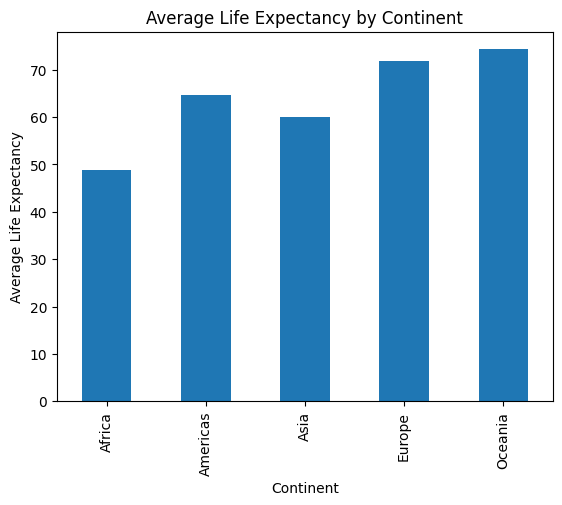

In [15]:
avg_life = df.groupby("continent")["lifeExp"].mean()

# Create bar chart
avg_life.plot(kind="bar")

# Add title and labels
plt.title("Average Life Expectancy by Continent")
plt.xlabel("Continent")
plt.ylabel("Average Life Expectancy")

# Display the chart
plt.show()

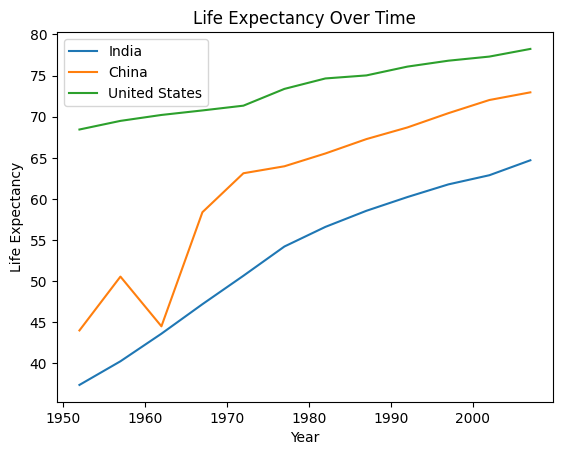

In [16]:
# Select only India, China, and United States
countries = ["India", "China", "United States"]
filtered_df = df[df["country"].isin(countries)]

# Create line chart
for country in countries:
    country_data = filtered_df[filtered_df["country"] == country]
    plt.plot(country_data["year"], country_data["lifeExp"], label=country)

# Add title and labels
plt.title("Life Expectancy Over Time")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.legend()

# Show chart
plt.show()

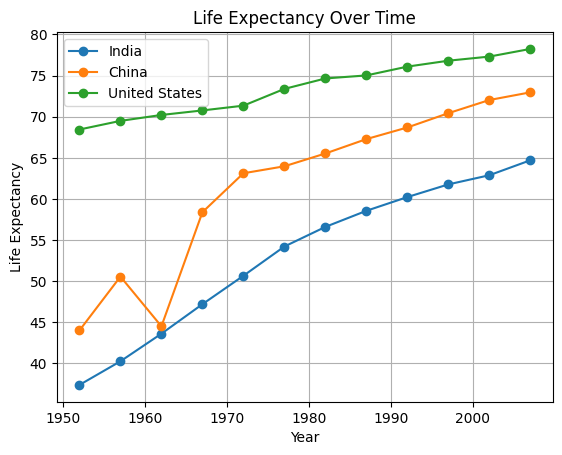

In [17]:
# Filter data
countries = ["India", "China", "United States"]
filtered_df = df[df["country"].isin(countries)]

# Plot line chart with dots
for country in countries:
    country_data = filtered_df[filtered_df["country"] == country]

    plt.plot(
        country_data["year"],
        country_data["lifeExp"],
        marker='o',      # Adds dots
        label=country
    )

# Labels and title
plt.title("Life Expectancy Over Time")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.legend()
plt.grid(True)

# Show chart
plt.show()

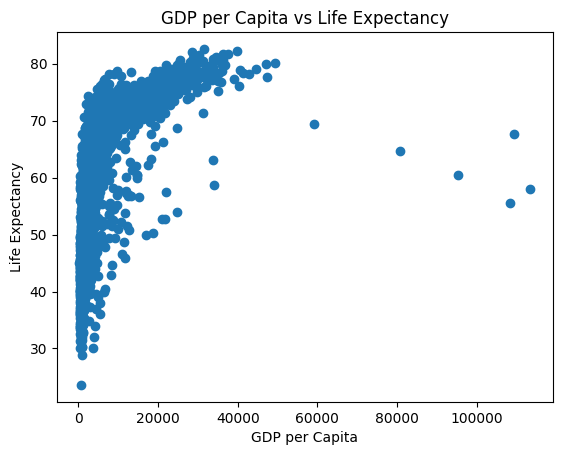

In [20]:
# Create scatter plot
plt.scatter(df["gdpPercap"], df["lifeExp"])

# Add title and labels
plt.title("GDP per Capita vs Life Expectancy")
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")

# Display chart
plt.show()